Attempting to fetch data from Alpha Vantage...
Trying symbol: STX40.JO
No data found for symbol: STX40.JO. Retrying after 10 seconds...
Trying symbol: JSE:STX40
No data found for symbol: JSE:STX40. Retrying after 10 seconds...
Trying symbol: STX40
No data found for symbol: STX40. Retrying after 10 seconds...

No real data found. Generating simulated data...


,open,high,low,close,volume
2025-05-03,7716.38,7824.62,7639.06,7731.84,552717
2025-05-04,7692.66,7800.58,7615.58,7708.08,660522
2025-05-05,7860.92,7971.19,7782.15,7876.67,496021
2025-05-06,7923.73,8034.88,7844.33,7939.61,367718
2025-05-07,7871.80,7982.22,7792.92,7887.57,475539



Running Linear Regression...


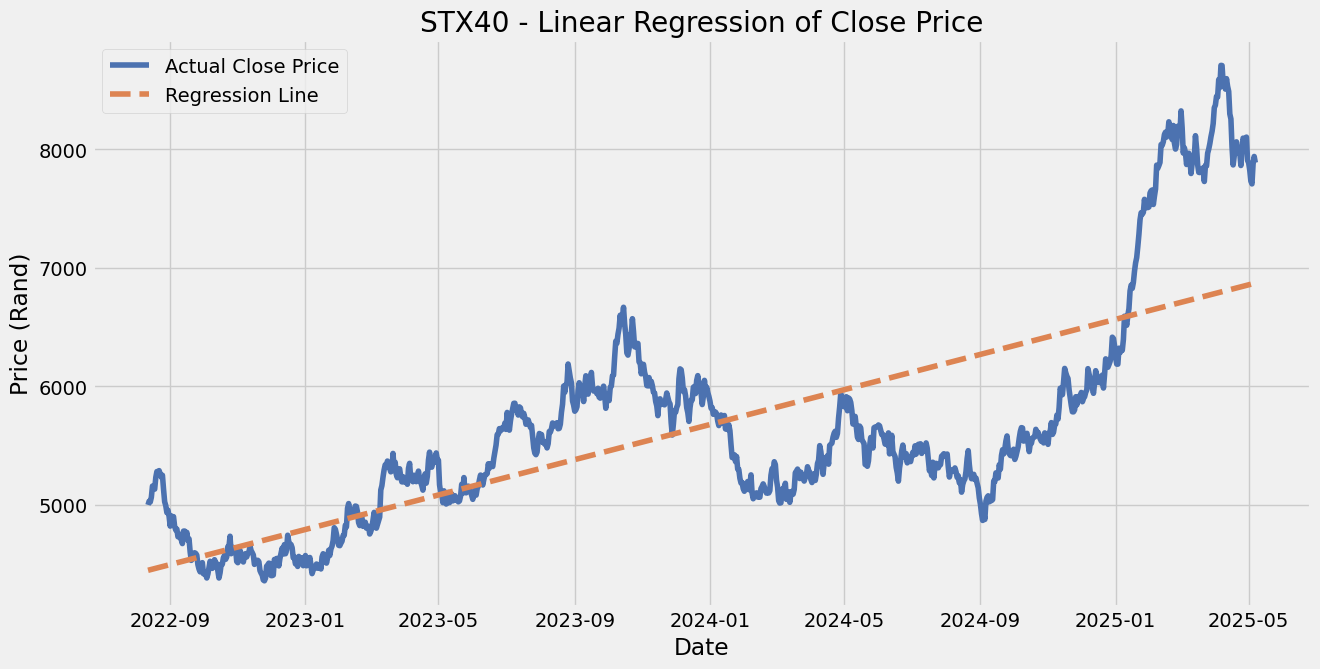

Regression Coefficient (slope): 2.4252
Regression Intercept: -1786281.58
Predicted price for 2027-05-08: R8644.27


In [7]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from IPython.display import display


plt.style.use('fivethirtyeight')
sns.set_palette("deep")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

API_KEY = "L4J2CUUF01MXGFMA"


def get_alpha_vantage_data(function, symbol, **kwargs):
    base_url = "https://www.alphavantage.co/query"
    params = {
        "function": function,
        "symbol": symbol,
        "apikey": API_KEY
    }
    params.update(kwargs)
    response = requests.get(base_url, params=params)
    data = response.json()
    return data


symbol_formats = ["STX40.JO", "JSE:STX40", "STX40"]
daily_data = None

print("Attempting to fetch data from Alpha Vantage...")
for symbol in symbol_formats:
    print(f"Trying symbol: {symbol}")
    data = get_alpha_vantage_data("TIME_SERIES_DAILY", symbol, outputsize="full")
    if data and "Time Series (Daily)" in data:
        print(f"Data successfully fetched using symbol: {symbol}")
        daily_data = data
        break
    else:
        print(f"No data found for symbol: {symbol}. Retrying after 10 seconds...")
        time.sleep(10)


if daily_data is None:
    print("\nNo real data found. Generating simulated data...")

    today = datetime.now()
    dates = [(today - timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1000, 0, -1)]
    
    np.random.seed(42)
    price = 5000  # starting price
    prices = [price]
    for i in range(1, len(dates)):
        daily_return = np.random.normal(0.0003, 0.012)
        price = price * (1 + daily_return)
        prices.append(price)
    
    time_series = {}
    for i, date in enumerate(dates):
        time_series[date] = {
            "1. open": str(round(prices[i] * 0.998, 2)),
            "2. high": str(round(prices[i] * 1.012, 2)),
            "3. low": str(round(prices[i] * 0.988, 2)),
            "4. close": str(round(prices[i], 2)),
            "5. volume": str(int(np.random.normal(500000, 150000)))
        }
    
    daily_data = {
        "Meta Data": {
            "1. Information": "Daily Prices (open, high, low, close) and Volumes",
            "2. Symbol": "STX40.JO (Simulated Data)",
            "3. Last Refreshed": datetime.now().strftime('%Y-%m-%d'),
            "4. Output Size": "Full size",
            "5. Time Zone": "US/Eastern"
        },
        "Time Series (Daily)": time_series
    }


time_series = daily_data["Time Series (Daily)"]
df = pd.DataFrame.from_dict(time_series, orient='index')
df.columns = [col.split('. ')[1] for col in df.columns]


numeric_columns = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])


df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df = df.iloc[-1500:]  # Keep recent 1500 records

display(df.tail())


print("\nRunning Linear Regression...")

# Prepare data for regression (using 'close' price)
df = df.dropna(subset=['close'])
df['ordinal_date'] = df.index.map(datetime.toordinal)

X = df['ordinal_date'].values.reshape(-1, 1)
y = df['close'].values

model = LinearRegression()
model.fit(X, y)

df['predicted'] = model.predict(X)


plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close'], label='Actual Close Price')
plt.plot(df.index, df['predicted'], label='Regression Line', linestyle='--')
plt.title('STX40 - Linear Regression of Close Price')
plt.xlabel('Date')
plt.ylabel('Price (Rand)')
plt.legend()
plt.show()


print(f"Regression Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Regression Intercept: {model.intercept_:.2f}")


future_date = datetime.today() + timedelta(days=365*2)
predicted_price = model.predict(np.array([[future_date.toordinal()]]))[0]
print(f"Predicted price for {future_date.date()}: R{predicted_price:.2f}")
